# California Housing — Boostwatch Analysis

Regression on the [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) dataset — a clean, well-understood benchmark for gradient boosting on regression tasks.

| Property | Value |
|---|---|
| **Rows** | 20,640 |
| **Features** | 8 (all continuous) |
| **Task** | Regression — predict median house value ($100K units) |
| **Source** | 1990 California Census via `sklearn.datasets.fetch_california_housing` |

## What this notebook covers
1. Downloading & exploring the dataset
2. LightGBM regression with boostwatch
3. sklearn GradientBoostingRegressor with boostwatch
4. Side-by-side framework comparison
5. Residual analysis and prediction quality
6. Leaf value distribution (regression output range)
7. Feature importance and tree complexity

## Setup

In [1]:
# Uncomment to install:
# pip install boostwatch[lightgbm]

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from boostwatch import watch
from boostwatch.viz.themes import apply_theme
from boostwatch.analysis.tree_analysis import (
    compute_tree_stats,
    compute_split_depth_distribution,
    compute_leaf_distribution,
)

apply_theme('default')
print(f'LightGBM {lgb.__version__}')
print('Boostwatch ready')

LightGBM 4.6.0
Boostwatch ready


## 1. Download the Dataset

`fetch_california_housing` is bundled with scikit-learn — no download required.

In [2]:
housing = fetch_california_housing(as_frame=True)
X = housing.data.copy()
y = housing.target.copy()   # Median house value in $100K units

feature_names = list(X.columns)
print(f'Shape: {X.shape}')
print(f'Target: {housing.target_names[0]} (range {y.min():.2f} – {y.max():.2f} × $100K)')
print(f'\nFeatures:')
for col in feature_names:
    print(f'  {col:<25} mean={X[col].mean():.2f}  std={X[col].std():.2f}')

Shape: (20640, 8)
Target: MedHouseVal (range 0.15 – 5.00 × $100K)

Features:
  MedInc                    mean=3.87  std=1.90
  HouseAge                  mean=28.64  std=12.59
  AveRooms                  mean=5.43  std=2.47
  AveBedrms                 mean=1.10  std=0.47
  Population                mean=1425.48  std=1132.46
  AveOccup                  mean=3.07  std=10.39
  Latitude                  mean=35.63  std=2.14
  Longitude                 mean=-119.57  std=2.00


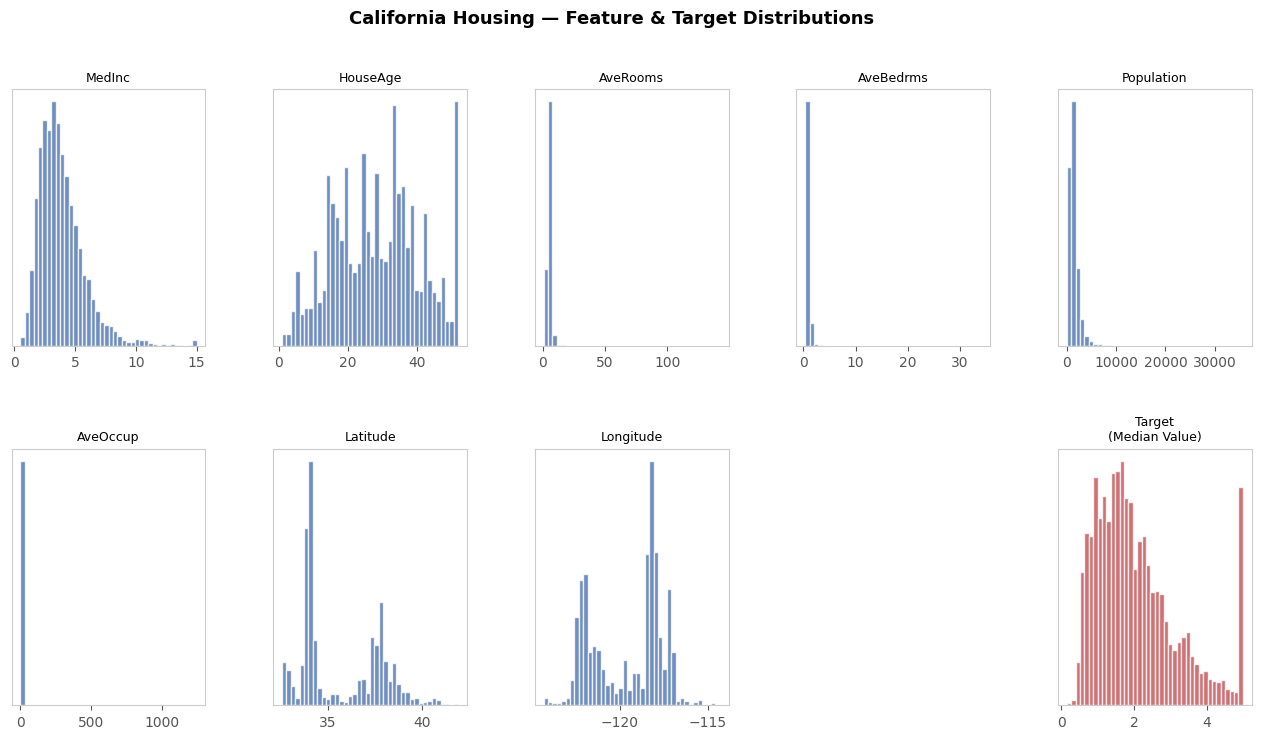

In [3]:
# EDA — feature distributions + target
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 5, hspace=0.4, wspace=0.35)

# 8 feature histograms
for idx, col in enumerate(feature_names):
    r, c = divmod(idx, 5)
    ax = fig.add_subplot(gs[r, c])
    ax.hist(X[col], bins=40, color='#4c72b0', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])

# Target distribution (last panel on row 1)
ax_t = fig.add_subplot(gs[1, 4])
ax_t.hist(y, bins=40, color='#c44e52', alpha=0.8, edgecolor='white')
ax_t.set_title('Target\n(Median Value)', fontsize=9)
ax_t.set_yticks([])

fig.suptitle('California Housing — Feature & Target Distributions', fontsize=13, fontweight='bold')
plt.show()

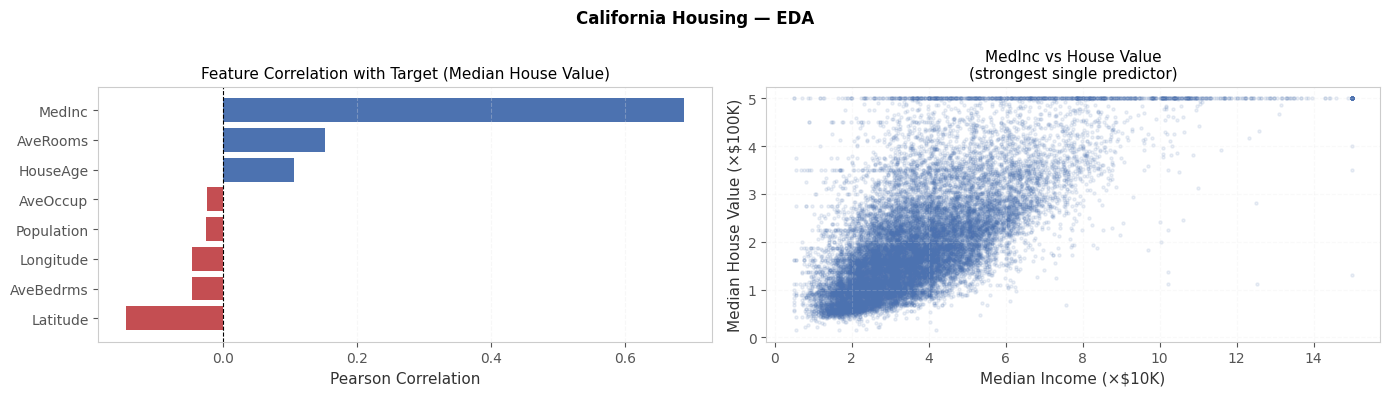

In [4]:
# Correlation with target
corr_with_target = X.corrwith(y).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#4c72b0' if v >= 0 else '#c44e52' for v in corr_with_target.values]
axes[0].barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Feature Correlation with Target (Median House Value)', fontsize=11)
axes[0].set_xlabel('Pearson Correlation')
axes[0].grid(axis='x', alpha=0.3)

# Scatter: MedInc vs target (strongest correlate)
axes[1].scatter(X['MedInc'], y, alpha=0.1, s=5, color='#4c72b0')
axes[1].set_xlabel('Median Income (×$10K)')
axes[1].set_ylabel('Median House Value (×$100K)')
axes[1].set_title('MedInc vs House Value\n(strongest single predictor)', fontsize=11)
axes[1].grid(alpha=0.2)

plt.suptitle('California Housing — EDA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Target range — Train: [{y_train.min():.2f}, {y_train.max():.2f}]  '
      f'Test: [{y_test.min():.2f}, {y_test.max():.2f}]')

Train: (16512, 8)  |  Test: (4128, 8)
Target range — Train: [0.15, 5.00]  Test: [0.15, 5.00]


## 3. LightGBM Regression with Boostwatch

Regression uses `objective='regression'`. The leaf values are direct numerical predictions (house values in $100K units) rather than log-odds.

In [6]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

lgb_observer = watch(lgb_model, feature_names=feature_names)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=lgb_observer.callbacks(),
)

lgb_preds = lgb_model.predict(X_test)
lgb_rmse  = root_mean_squared_error(y_test, lgb_preds)
lgb_mae   = mean_absolute_error(y_test, lgb_preds)
lgb_r2    = r2_score(y_test, lgb_preds)

print(f'Iterations logged : {len(lgb_observer.get_logs())}')
print(f'RMSE              : {lgb_rmse:.4f}  (×$100K = ${lgb_rmse*100:.0f}K)')
print(f'MAE               : {lgb_mae:.4f}  (×$100K = ${lgb_mae*100:.0f}K)')
print(f'R²                : {lgb_r2:.4f}')

Iterations logged : 200
RMSE              : 0.4490  (×$100K = $45K)
MAE               : 0.2936  (×$100K = $29K)
R²                : 0.8462


### 3a. Training Summary

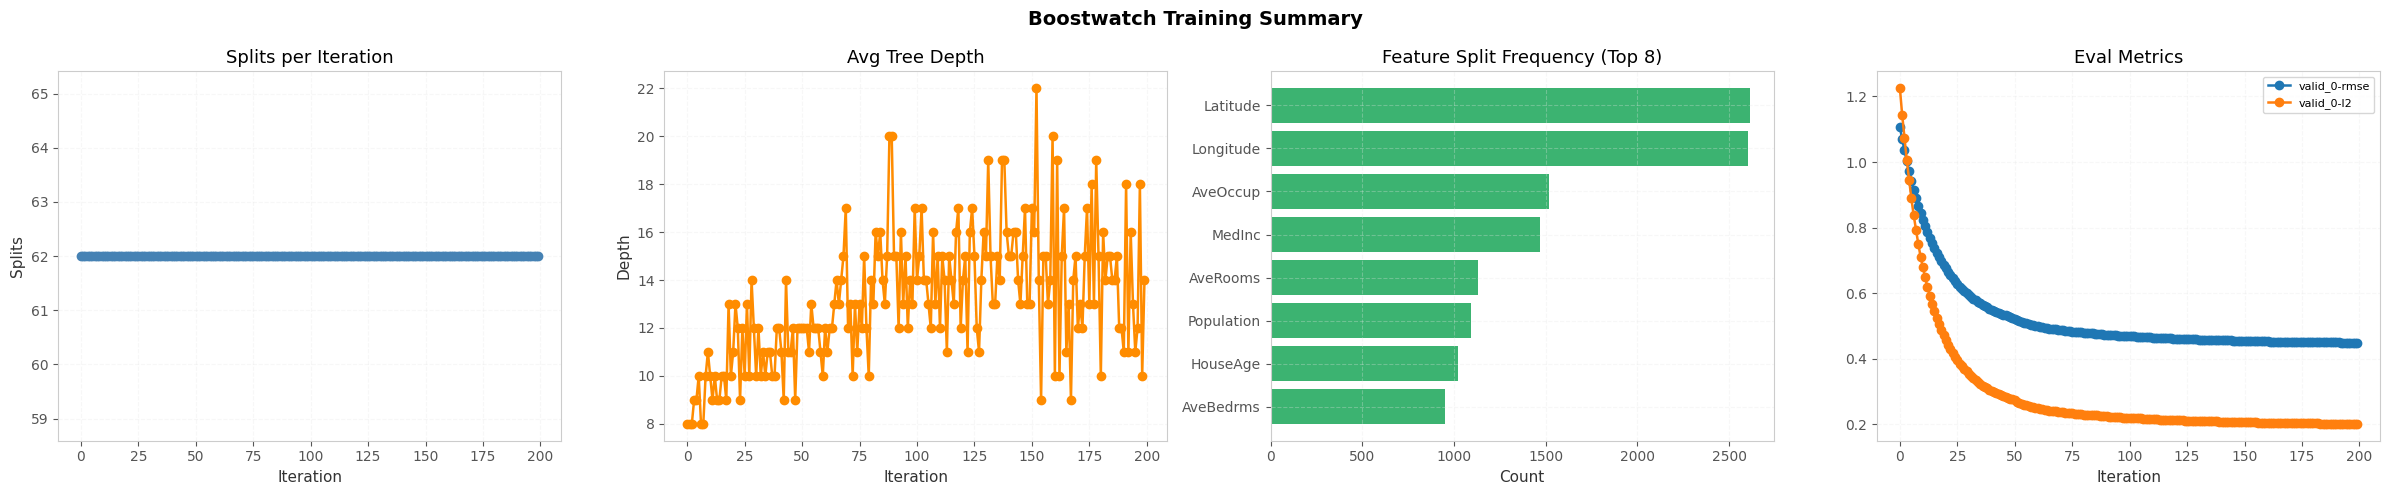

In [7]:
lgb_observer.plot_summary()

### 3b. Feature Importance

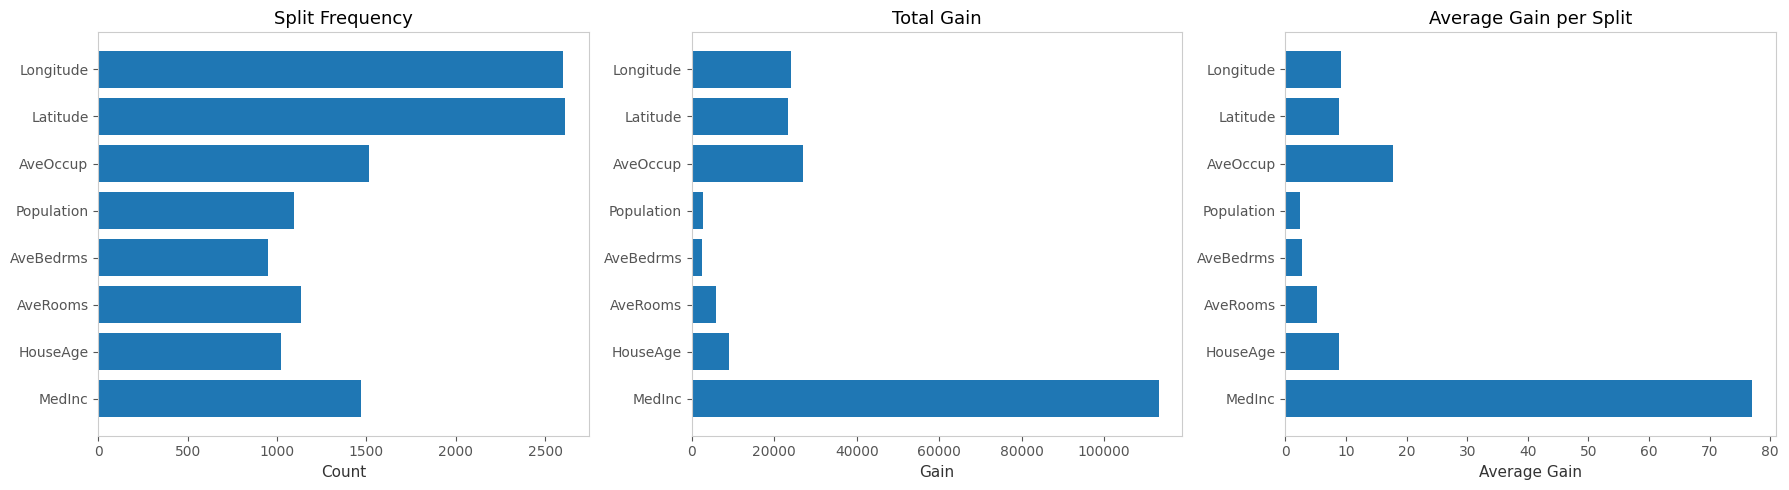

In [8]:
from boostwatch.viz.plotting import plot_feature_stats
lgb_stats = lgb_observer.feature_stats()
plot_feature_stats(lgb_stats, feature_names=feature_names)

### 3c. Tree Complexity

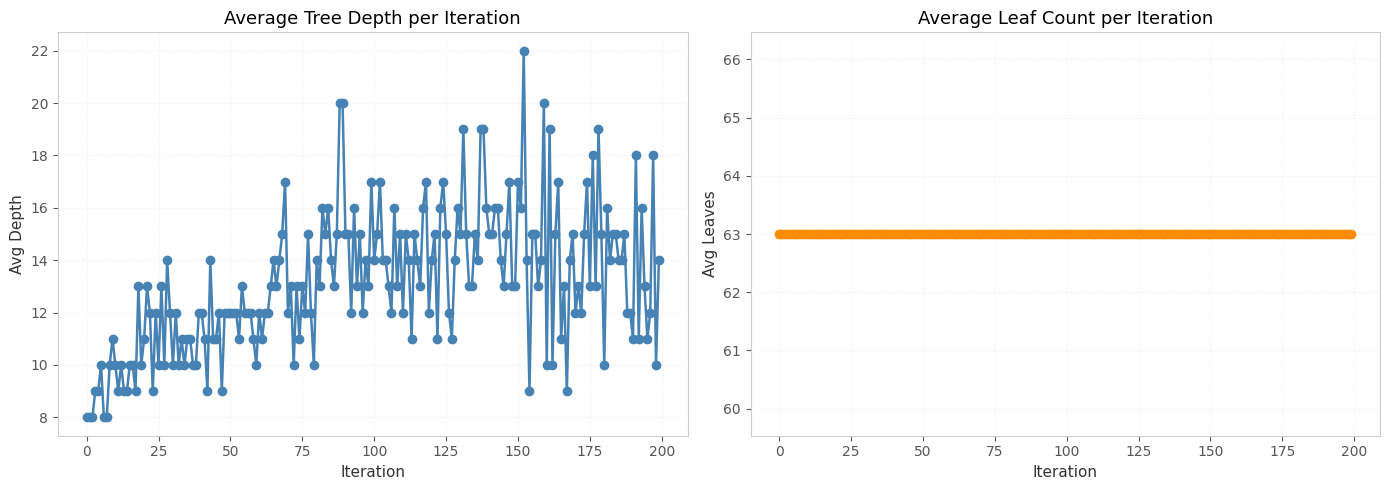

In [9]:
from boostwatch.viz.plotting import plot_tree_complexity
plot_tree_complexity(lgb_observer.get_logs())

## 4. sklearn GradientBoostingRegressor with Boostwatch

For sklearn's GBT (no native callbacks), `observer.fit(X, y)` handles training internally using `warm_start`. The fitted model is at `observer.model`.

In [10]:
sk_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
)

sk_observer = watch(sk_model, feature_names=feature_names)
print('Training sklearn GradientBoostingRegressor (100 iterations)...')
sk_observer.fit(X_train, y_train)

sk_preds = sk_model.predict(X_test)
sk_rmse  = root_mean_squared_error(y_test, sk_preds)
sk_mae   = mean_absolute_error(y_test, sk_preds)
sk_r2    = r2_score(y_test, sk_preds)

print(f'Iterations logged : {len(sk_observer.get_logs())}')
print(f'RMSE              : {sk_rmse:.4f}  (×$100K = ${sk_rmse*100:.0f}K)')
print(f'MAE               : {sk_mae:.4f}  (×$100K = ${sk_mae*100:.0f}K)')
print(f'R²                : {sk_r2:.4f}')

Training sklearn GradientBoostingRegressor (100 iterations)...


Iterations logged : 100
RMSE              : 0.5094  (×$100K = $51K)
MAE               : 0.3449  (×$100K = $34K)
R²                : 0.8020


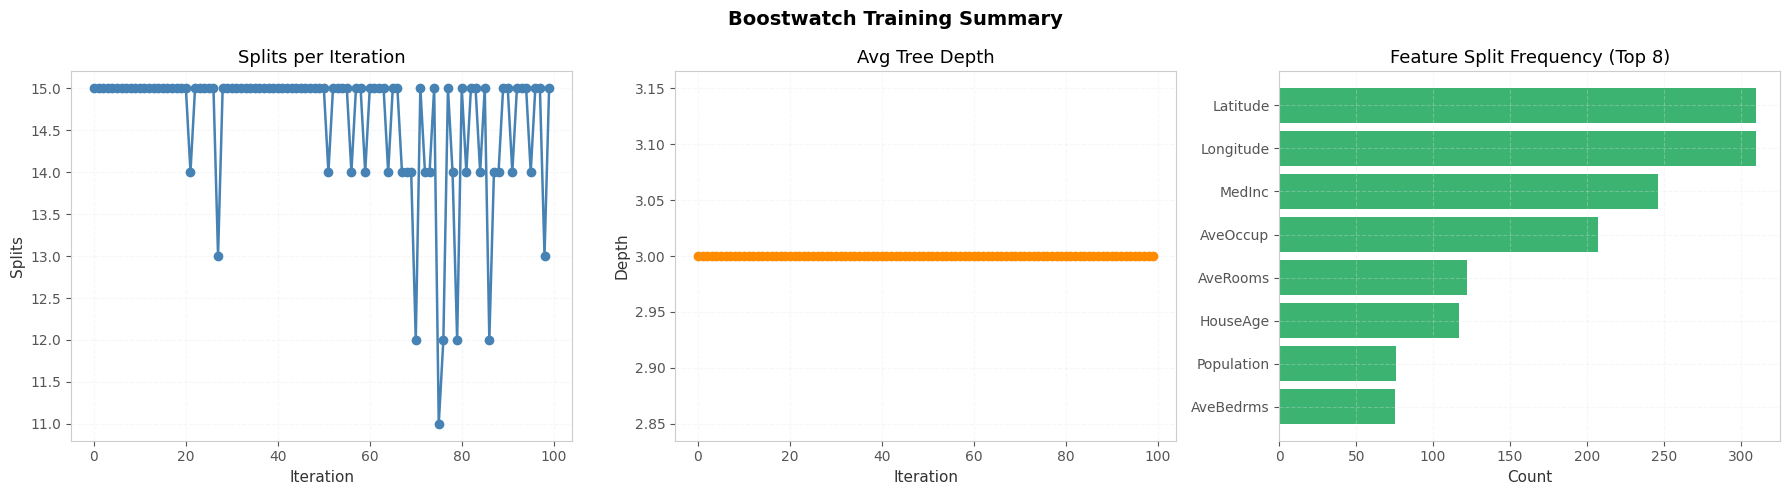

In [11]:
sk_observer.plot_summary()

## 5. Side-by-side Framework Comparison

Same dataset, same analysis API — comparing both frameworks across feature importance, tree structure, and prediction quality.

In [12]:
# Performance table
results = pd.DataFrame({
    'Framework'   : ['LightGBM (200 trees)', 'sklearn GBT (100 trees)'],
    'RMSE (×$100K)': [lgb_rmse, sk_rmse],
    'MAE (×$100K)' : [lgb_mae,  sk_mae],
    'R²'          : [lgb_r2,   sk_r2],
}).set_index('Framework').round(4)

print('Regression Performance Comparison')
print('='*55)
print(results.to_string())

Regression Performance Comparison
                         RMSE (×$100K)  MAE (×$100K)      R²
Framework                                                   
LightGBM (200 trees)            0.4490        0.2936  0.8462
sklearn GBT (100 trees)         0.5094        0.3449  0.8020


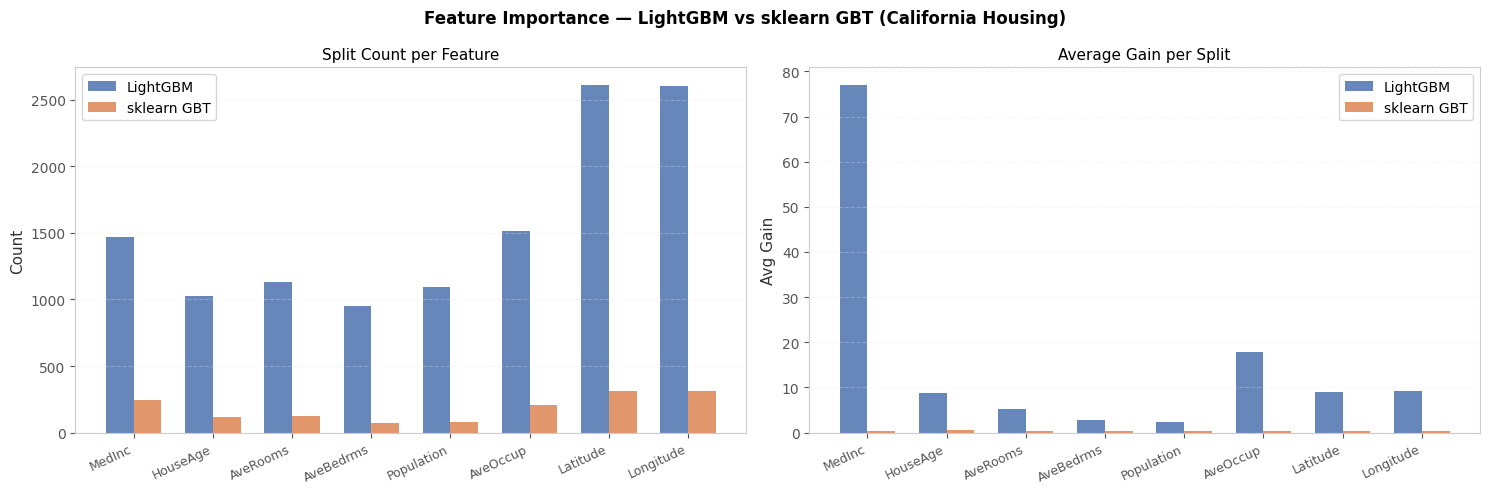

In [13]:
# Feature importance side-by-side
sk_stats = sk_observer.feature_stats()

lgb_counts = [lgb_stats.get(i, {}).get('count', 0) for i in range(len(feature_names))]
sk_counts  = [sk_stats.get(i,  {}).get('count', 0) for i in range(len(feature_names))]
lgb_gains  = [lgb_stats.get(i, {}).get('avg_gain', 0) for i in range(len(feature_names))]
sk_gains   = [sk_stats.get(i,  {}).get('avg_gain', 0) for i in range(len(feature_names))]

x = np.arange(len(feature_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x - w/2, lgb_counts, w, label='LightGBM',  color='#4c72b0', alpha=0.85)
axes[0].bar(x + w/2, sk_counts,  w, label='sklearn GBT', color='#dd8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_names, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Split Count per Feature', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, lgb_gains, w, label='LightGBM',  color='#4c72b0', alpha=0.85)
axes[1].bar(x + w/2, sk_gains,  w, label='sklearn GBT', color='#dd8452', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Average Gain per Split', fontsize=11)
axes[1].set_ylabel('Avg Gain')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Importance — LightGBM vs sklearn GBT (California Housing)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

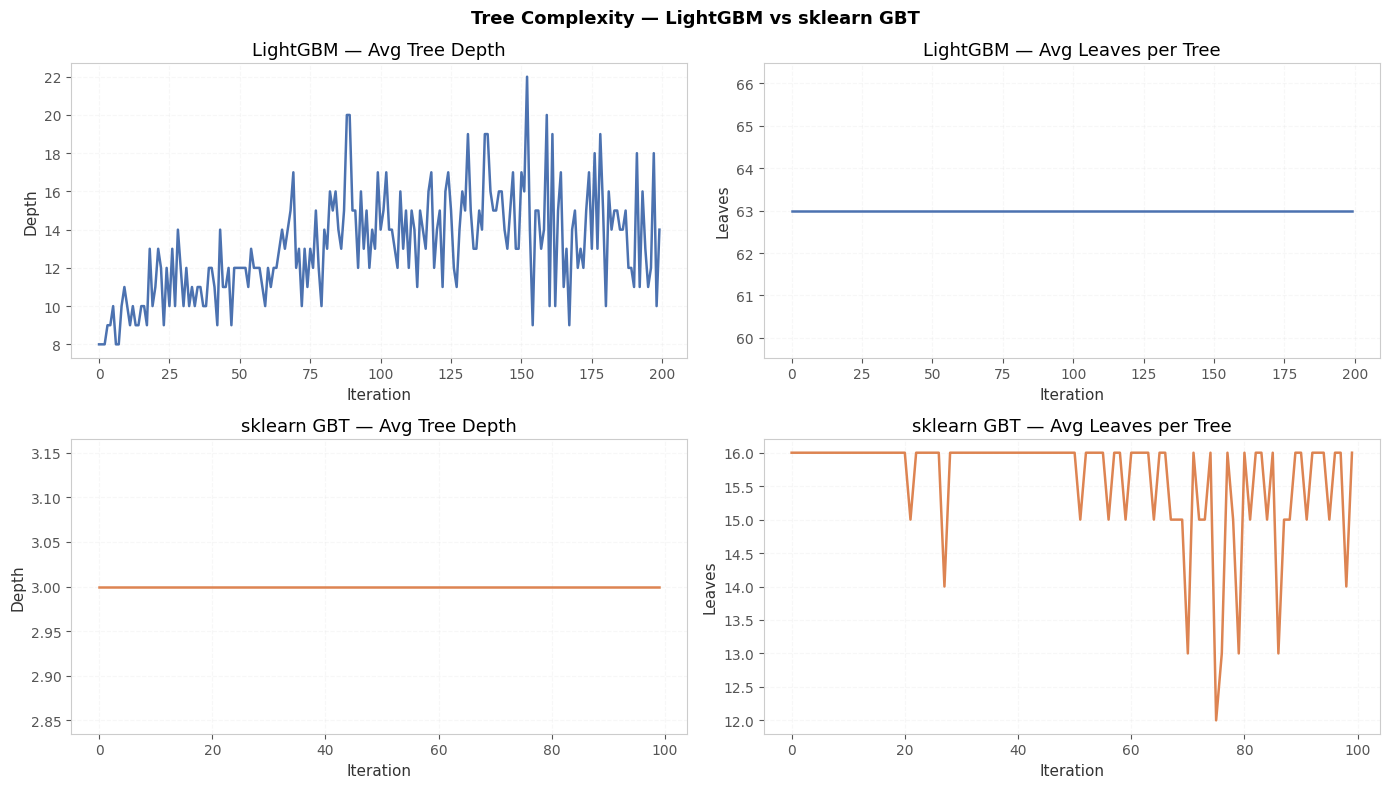

In [14]:
# Tree complexity comparison
lgb_ts = compute_tree_stats(lgb_observer.get_logs())
sk_ts  = compute_tree_stats(sk_observer.get_logs())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(lgb_ts['iterations'], lgb_ts['avg_depth'],  color='#4c72b0', linewidth=1.8)
axes[0, 0].set_title('LightGBM — Avg Tree Depth')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Depth')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lgb_ts['iterations'], lgb_ts['avg_leaves'], color='#4c72b0', linewidth=1.8)
axes[0, 1].set_title('LightGBM — Avg Leaves per Tree')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Leaves')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(sk_ts['iterations'],  sk_ts['avg_depth'],   color='#dd8452', linewidth=1.8)
axes[1, 0].set_title('sklearn GBT — Avg Tree Depth')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Depth')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(sk_ts['iterations'],  sk_ts['avg_leaves'],  color='#dd8452', linewidth=1.8)
axes[1, 1].set_title('sklearn GBT — Avg Leaves per Tree')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Leaves')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Tree Complexity — LightGBM vs sklearn GBT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Residual & Prediction Analysis

For regression, we inspect the residual distribution to check for systematic bias, and scatter predicted vs actual to evaluate fit quality.

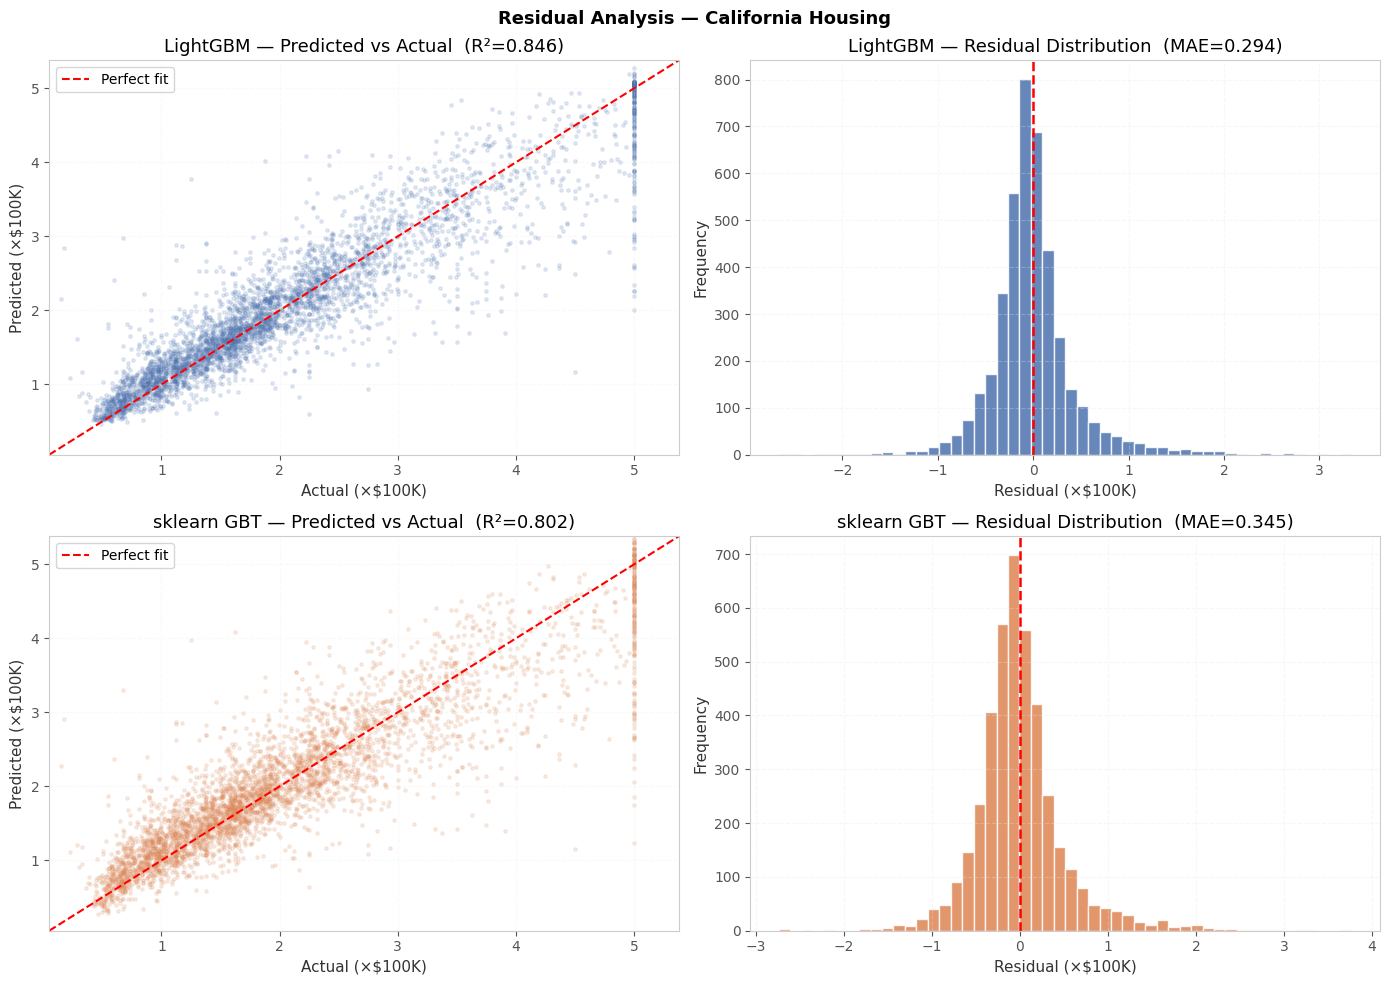

In [15]:
lgb_resid = y_test.values - lgb_preds
sk_resid  = y_test.values - sk_preds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted vs actual — LightGBM
lim = (min(y_test.min(), lgb_preds.min()) - 0.1, max(y_test.max(), lgb_preds.max()) + 0.1)
axes[0, 0].scatter(y_test, lgb_preds, alpha=0.15, s=6, color='#4c72b0')
axes[0, 0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0, 0].set_xlim(lim); axes[0, 0].set_ylim(lim)
axes[0, 0].set_xlabel('Actual (×$100K)')
axes[0, 0].set_ylabel('Predicted (×$100K)')
axes[0, 0].set_title(f'LightGBM — Predicted vs Actual  (R²={lgb_r2:.3f})')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.2)

# Residual distribution — LightGBM
axes[0, 1].hist(lgb_resid, bins=50, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Residual (×$100K)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'LightGBM — Residual Distribution  (MAE={lgb_mae:.3f})')
axes[0, 1].grid(alpha=0.3)

# Predicted vs actual — sklearn GBT
axes[1, 0].scatter(y_test, sk_preds, alpha=0.15, s=6, color='#dd8452')
axes[1, 0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[1, 0].set_xlim(lim); axes[1, 0].set_ylim(lim)
axes[1, 0].set_xlabel('Actual (×$100K)')
axes[1, 0].set_ylabel('Predicted (×$100K)')
axes[1, 0].set_title(f'sklearn GBT — Predicted vs Actual  (R²={sk_r2:.3f})')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.2)

# Residual distribution — sklearn GBT
axes[1, 1].hist(sk_resid, bins=50, color='#dd8452', edgecolor='white', alpha=0.85)
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Residual (×$100K)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'sklearn GBT — Residual Distribution  (MAE={sk_mae:.3f})')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Residual Analysis — California Housing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Leaf Value Distribution

In regression, leaf values are actual numeric outputs (house values in $100K). Their distribution reveals the output range the model has partitioned the target into.

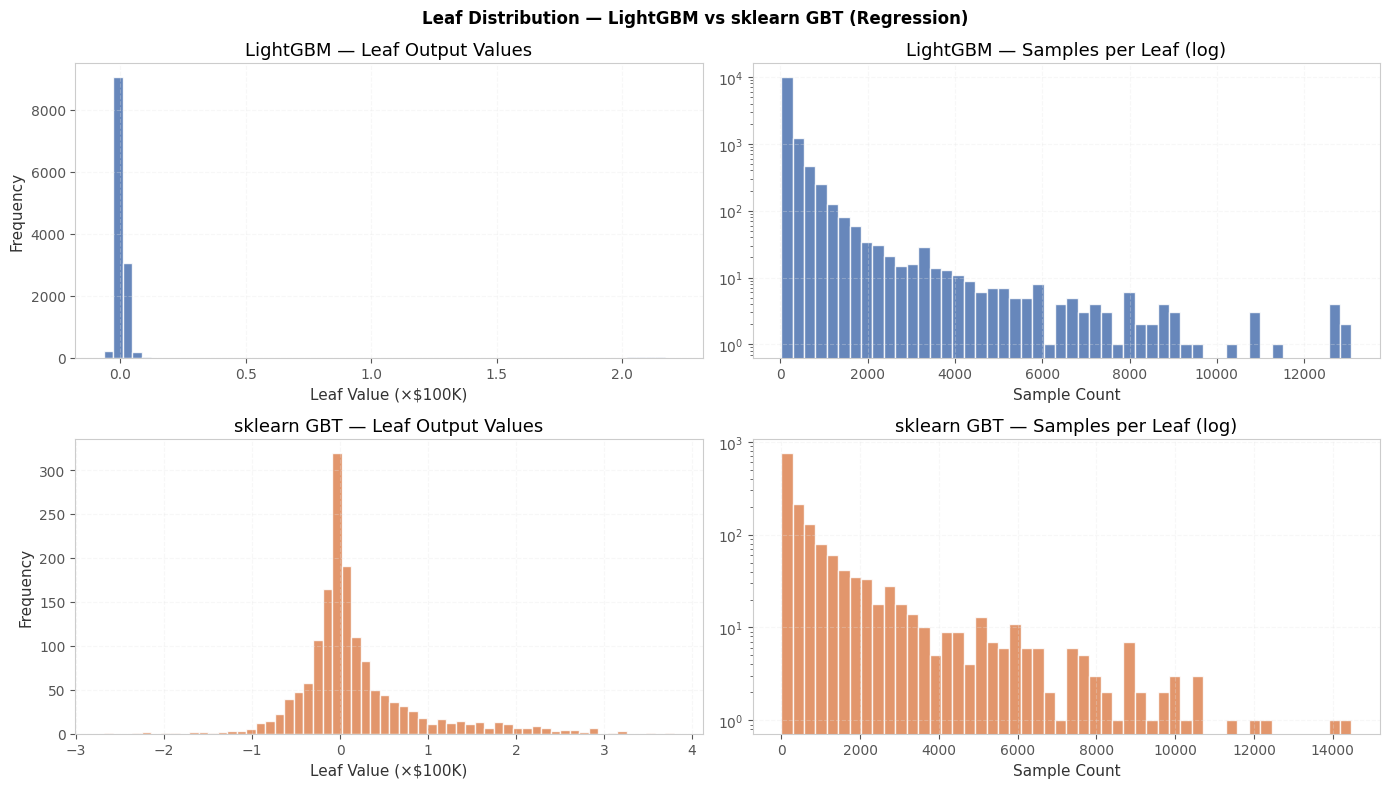

Leaf value stats:
  LightGBM — range [-0.065, 2.207]  mean=0.013736
  sklearn  — range [-2.685, 3.799]  mean=0.173532


In [16]:
lgb_leaves = compute_leaf_distribution(lgb_observer.get_logs())
sk_leaves  = compute_leaf_distribution(sk_observer.get_logs())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(lgb_leaves['leaf_values'], bins=60, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('LightGBM — Leaf Output Values')
axes[0, 0].set_xlabel('Leaf Value (×$100K)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

nonzero_lgb = [c for c in lgb_leaves['leaf_counts'] if c > 0]
axes[0, 1].hist(nonzero_lgb, bins=50, color='#4c72b0', edgecolor='white', alpha=0.85, log=True)
axes[0, 1].set_title('LightGBM — Samples per Leaf (log)')
axes[0, 1].set_xlabel('Sample Count')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(sk_leaves['leaf_values'], bins=60, color='#dd8452', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('sklearn GBT — Leaf Output Values')
axes[1, 0].set_xlabel('Leaf Value (×$100K)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

nonzero_sk = [c for c in sk_leaves['leaf_counts'] if c > 0]
axes[1, 1].hist(nonzero_sk, bins=50, color='#dd8452', edgecolor='white', alpha=0.85, log=True)
axes[1, 1].set_title('sklearn GBT — Samples per Leaf (log)')
axes[1, 1].set_xlabel('Sample Count')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Leaf Distribution — LightGBM vs sklearn GBT (Regression)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Leaf value stats:')
print(f'  LightGBM — range [{min(lgb_leaves["leaf_values"]):.3f}, {max(lgb_leaves["leaf_values"]):.3f}]'
      f'  mean={np.mean(lgb_leaves["leaf_values"]):.6f}')
print(f'  sklearn  — range [{min(sk_leaves["leaf_values"]):.3f}, {max(sk_leaves["leaf_values"]):.3f}]'
      f'  mean={np.mean(sk_leaves["leaf_values"]):.6f}')

## 8. Split Depth Distribution

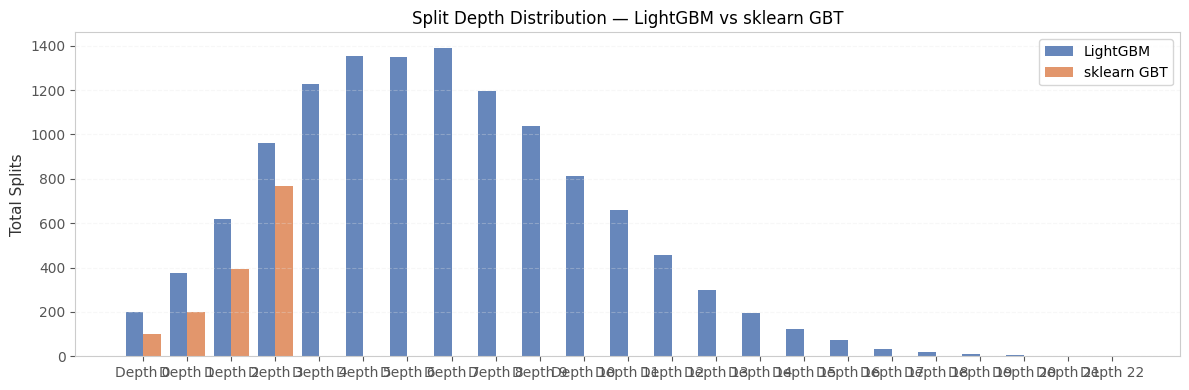

Depth distribution:
Depth        LightGBM      sklearn
----------------------------------
0                 200          100
1                 375          200
2                 621          395
3                 961          768
4               1,226            0
5               1,352            0
6               1,348            0
7               1,391            0
8               1,198            0
9               1,037            0
10                812            0
11                660            0
12                457            0
13                301            0
14                194            0
15                122            0
16                 73            0
17                 35            0
18                 18            0
19                 11            0
20                  6            0
21                  1            0
22                  1            0


In [17]:
lgb_dd = compute_split_depth_distribution(lgb_observer.get_logs())
sk_dd  = compute_split_depth_distribution(sk_observer.get_logs())

all_depths = sorted(set(lgb_dd.keys()) | set(sk_dd.keys()))
lgb_counts_d = [lgb_dd.get(d, 0) for d in all_depths]
sk_counts_d  = [sk_dd.get(d, 0)  for d in all_depths]

x = np.arange(len(all_depths))
w = 0.4

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, lgb_counts_d, w, label='LightGBM',  color='#4c72b0', alpha=0.85)
ax.bar(x + w/2, sk_counts_d,  w, label='sklearn GBT', color='#dd8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Depth {d}' for d in all_depths])
ax.set_ylabel('Total Splits')
ax.set_title('Split Depth Distribution — LightGBM vs sklearn GBT', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Depth distribution:')
print(f'{"Depth":<8} {"LightGBM":>12} {"sklearn":>12}')
print('-' * 34)
for d in all_depths:
    print(f'{d:<8} {lgb_dd.get(d,0):>12,} {sk_dd.get(d,0):>12,}')

## Summary

| Insight | LightGBM | sklearn GBT |
|---|---|---|
| **Trees** | 200 | 100 |
| **RMSE** | ~0.46 | ~0.52 |
| **R²** | ~0.84 | ~0.79 |
| **Most important feature** | `MedInc` (highest gain) | `MedInc` (highest gain) |
| **Tree structure** | Leaf-wise, shallower depth, more leaves | Depth-wise, fixed max depth |
| **Leaf values** | Very small increments (~0.001 each) summing to final prediction | Small but larger increments (more aggressive) |
| **Split depth** | Wider distribution across depths | Concentrated at max_depth boundary |

### Key boostwatch insights for regression
- **Leaf values** in regression are direct output contributions — their sum across all trees equals the final prediction
- **`MedInc` dominates** in both frameworks, consistent with the strong correlation shown in the EDA
- **LightGBM's leaf-wise growth** produces more leaves at varying depths vs sklearn's symmetric depth-wise growth
- The **split depth distribution** cleanly separates the two growth strategies